# Plaque–Vessel Spatial Relationship Analysis

This notebook explores the spatial relationship between Aβ plaques and blood vessels
(CD31 staining) using the signed distance transform (SDT) from each plaque surface
to the nearest vessel wall.

**SDT convention (`sdt_CD31`):**
- `< 0` → plaque is *inside* / overlapping the vessel (and the magnitude indicates
  how far the plaque surface reaches into the vessel lumen)
- `= 0` → plaque surface just touches the vessel wall
- `> 0` → plaque is *outside* the vessel; value = distance to nearest vessel (mm)

## Outline
1. Setup & data loading  
2. SDT distribution (ECDF, histogram) by treatment & genotype  
3. Plaque–vessel classification: *inside*, *near*, *far*  
4. Subject-level proximity fractions & boxplots  
5. Two-way ANOVA (treatment × genotype) for proximity fractions  
6. Intravascular plaques: vessel-calibre estimation from SDT  
7. Subject-level vessel-calibre summaries  
8. 2-D spatial maps coloured by vessel-proximity category  

## 1  Setup & data loading

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings("ignore", category=FutureWarning)

# ── aesthetics ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
TREAT_ORDER   = ["PBS", "Lecanemab"]
TREAT_PALETTE = {"PBS": "#4C72B0", "Lecanemab": "#DD8452"}
GENO_ORDER    = ["ApoE3", "ApoE4"]
GENO_PALETTE  = {"ApoE3": "#55A868", "ApoE4": "#C44E52"}

# ── analysis parameters ───────────────────────────────────────────────────────
VOL_THRESH_ML = 1e-4   # remove implausibly large plaques (same as other notebooks)
TAU_UM        = 5.0    # boundary between "near vessel" and "far from vessel" (µm)

# vessel-diameter bins for intravascular plaques
VESSEL_BINS_UM     = [0, 10, 20, np.inf]
VESSEL_BIN_LABELS  = ["<10 µm", "10–20 µm", ">20 µm"]

In [2]:
# ── load & pre-process ────────────────────────────────────────────────────────
df_raw = pd.read_parquet("data.parquet")

df = df_raw.loc[df_raw["plaque_vol_ml"] <= VOL_THRESH_ML].copy()
df["treatment"] = pd.Categorical(df["treatment"], categories=TREAT_ORDER, ordered=True)
df["genotype"]  = pd.Categorical(df["genotype"],  categories=GENO_ORDER,  ordered=True)

# sdt_CD31_um is already in µm; make sure column exists
if "sdt_CD31_um" not in df.columns:
    df["sdt_CD31_um"] = df["sdt_CD31"] * 1000.0

print(f"Plaques after size filter: {len(df):,}  (removed {len(df_raw)-len(df):,})")
print()
print(df.groupby(["treatment", "genotype"])["subject"].nunique()
        .rename("n_subjects").reset_index())

Plaques after size filter: 1,157,491  (removed 81,933)

   treatment genotype  n_subjects
0        PBS    ApoE3           3
1        PBS    ApoE4           5
2  Lecanemab    ApoE3           3
3  Lecanemab    ApoE4           5


## 2  SDT distribution by treatment & genotype

The signed distance transform (`sdt_CD31`, in mm) encodes how far each plaque is
from the nearest vessel.  Negative values indicate the plaque overlaps with or lies
inside the vessel lumen.

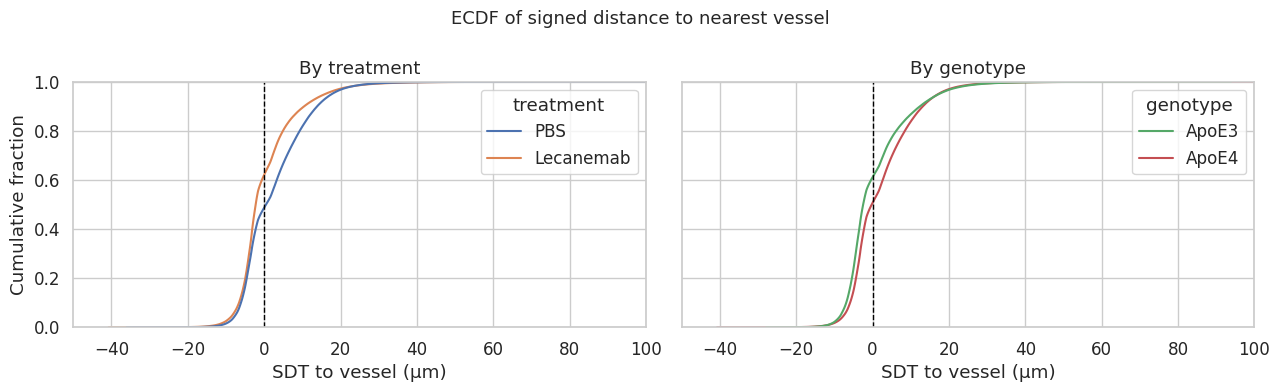

In [3]:
# ── ECDF of SDT by treatment ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, (hue_col, hue_order, palette) in zip(
    axes,
    [
        ("treatment", TREAT_ORDER, TREAT_PALETTE),
        ("genotype",  GENO_ORDER,  GENO_PALETTE),
    ],
):
    sns.ecdfplot(
        data=df,
        x="sdt_CD31_um",
        hue=hue_col,
        hue_order=hue_order,
        palette=palette,
        ax=ax,
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1, label="vessel wall")
    ax.set_xlabel("SDT to vessel (µm)")
    ax.set_ylabel("Cumulative fraction")
    ax.set_xlim(-50, 100)

axes[0].set_title("By treatment")
axes[1].set_title("By genotype")
fig.suptitle("ECDF of signed distance to nearest vessel", fontsize=13)
plt.tight_layout()
plt.savefig("fig_sdt_ecdf.png", dpi=150, bbox_inches="tight")
plt.show()

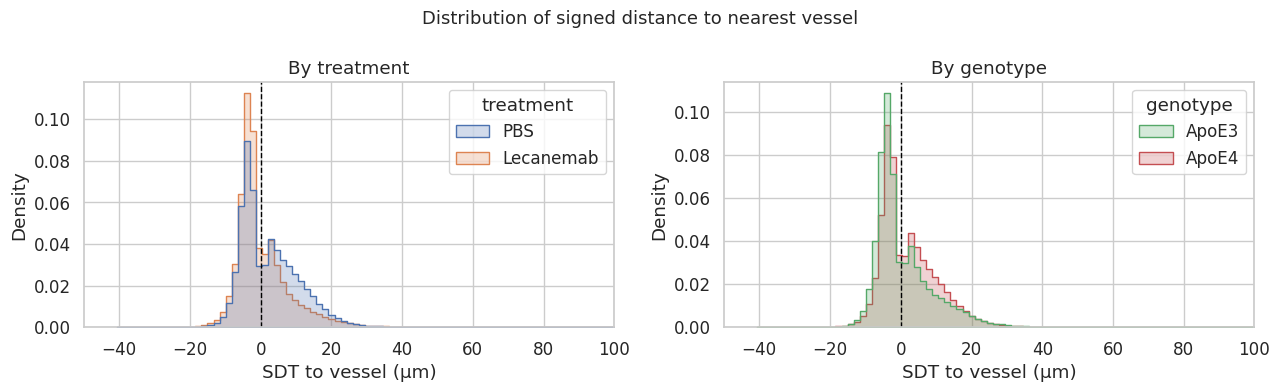

In [4]:
# ── Histogram / density of SDT ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (hue_col, hue_order, palette) in zip(
    axes,
    [
        ("treatment", TREAT_ORDER, TREAT_PALETTE),
        ("genotype",  GENO_ORDER,  GENO_PALETTE),
    ],
):
    sns.histplot(
        data=df,
        x="sdt_CD31_um",
        hue=hue_col,
        hue_order=hue_order,
        palette=palette,
        bins=100,
        stat="density",
        common_norm=False,
        element="step",
        ax=ax,
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("SDT to vessel (µm)")
    ax.set_xlim(-50, 100)

axes[0].set_title("By treatment")
axes[1].set_title("By genotype")
fig.suptitle("Distribution of signed distance to nearest vessel", fontsize=13)
plt.tight_layout()
plt.show()

## 3  Plaque–vessel classification

Plaques are classified into three mutually exclusive categories:

| Category | SDT criterion |
|---|---|
| **Inside vessel** | `sdt_CD31_um < 0` |
| **Near vessel** | `0 ≤ sdt_CD31_um < τ` (default τ = 5 µm) |
| **Far from vessel** | `sdt_CD31_um ≥ τ` |

For intravascular plaques the minimum compatible vessel diameter is estimated as:

$$d_{\text{vessel}} \geq d_{\text{plaque}} + 2 \cdot |\text{SDT}|$$

because the plaque centre is displaced by |SDT| beyond the plaque radius from the
vessel wall.

In [5]:
def classify_plaques(plaque_df, tau_um=TAU_UM,
                     vessel_bins_um=VESSEL_BINS_UM,
                     vessel_bin_labels=VESSEL_BIN_LABELS):
    """Add vessel-relation category and min-vessel-diameter estimate."""
    out = plaque_df.copy()

    # three-way proximity label
    out["vessel_relation"] = pd.cut(
        out["sdt_CD31_um"],
        bins=[-np.inf, 0, tau_um, np.inf],
        labels=[
            "inside vessel",
            f"near vessel (0–{tau_um:g} µm)",
            f"far from vessel (>{tau_um:g} µm)",
        ],
        include_lowest=True,
        right=True,
    )

    # minimum vessel diameter estimate for intravascular plaques
    # d_vessel ≥ d_plaque + 2 * |SDT|  (SDT < 0 inside vessel)
    out["min_vessel_diam_um"] = np.nan
    inside = out["sdt_CD31_um"] < 0
    out.loc[inside, "min_vessel_diam_um"] = (
        out.loc[inside, "equiv_diam_um"] - 2 * out.loc[inside, "sdt_CD31_um"]
    )

    # bin estimated minimum vessel diameter
    out["vessel_diam_bin"] = pd.cut(
        out["min_vessel_diam_um"],
        bins=vessel_bins_um,
        labels=vessel_bin_labels,
        include_lowest=True,
        right=False,
    )

    return out


df = classify_plaques(df)

print("Plaque counts by vessel-relation category:")
print(df["vessel_relation"].value_counts())
print()
print("Fractions:")
print((df["vessel_relation"].value_counts() / len(df)).round(4))

Plaque counts by vessel-relation category:
vessel_relation
inside vessel              622701
far from vessel (>5 µm)    325894
near vessel (0–5 µm)       208896
Name: count, dtype: int64

Fractions:
vessel_relation
inside vessel              0.5380
far from vessel (>5 µm)    0.2816
near vessel (0–5 µm)       0.1805
Name: count, dtype: float64


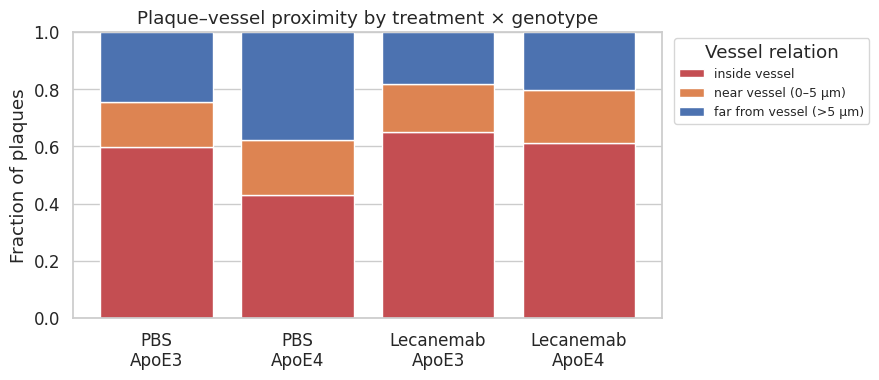

In [6]:
# ── Stacked bar: proportion in each category by treatment × genotype ──────────
cat_counts = (
    df.groupby(["treatment", "genotype", "vessel_relation"], observed=True)
    .size()
    .rename("n")
    .reset_index()
)
cat_totals = (
    df.groupby(["treatment", "genotype"], observed=True)
    .size()
    .rename("n_total")
    .reset_index()
)
cat_frac = cat_counts.merge(cat_totals, on=["treatment", "genotype"])
cat_frac["fraction"] = cat_frac["n"] / cat_frac["n_total"]

cat_pivot = cat_frac.pivot_table(
    index=["treatment", "genotype"],
    columns="vessel_relation",
    values="fraction",
).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
relation_cols = df["vessel_relation"].cat.categories.tolist()
colors = ["#C44E52", "#DD8452", "#4C72B0"]
bottom = np.zeros(len(cat_pivot))
x_labels = [f"{row.treatment}\n{row.genotype}" for _, row in cat_pivot.iterrows()]

for col, color in zip(relation_cols, colors):
    vals = cat_pivot[col].values
    ax.bar(x_labels, vals, bottom=bottom, label=col, color=color, edgecolor="white")
    bottom += vals

ax.set_ylabel("Fraction of plaques")
ax.set_ylim(0, 1)
ax.legend(title="Vessel relation", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.set_title("Plaque–vessel proximity by treatment × genotype")
plt.tight_layout()
plt.show()

## 4  Subject-level proximity fractions & boxplots

In [7]:
def subject_proximity_fractions(plaque_df,
                                group_cols=("subject", "genotype", "treatment", "sex")):
    """Per-subject fraction of plaques in each vessel-relation class."""
    counts = (
        plaque_df.groupby(list(group_cols) + ["vessel_relation"], observed=True)
        .size()
        .rename("n")
        .reset_index()
    )
    totals = (
        plaque_df.groupby(list(group_cols), observed=True)
        .size()
        .rename("n_total")
        .reset_index()
    )
    out = counts.merge(totals, on=list(group_cols))
    out["fraction"] = out["n"] / out["n_total"]
    out["percent"]  = 100 * out["fraction"]
    return out


subj_prox = subject_proximity_fractions(df)
print(subj_prox.head())

       subject genotype  treatment sex          vessel_relation      n  \
0  sub-AS161F3    ApoE3        PBS   F            inside vessel  43105   
1  sub-AS161F3    ApoE3        PBS   F     near vessel (0–5 µm)  11874   
2  sub-AS161F3    ApoE3        PBS   F  far from vessel (>5 µm)  19971   
3  sub-AS164F3    ApoE3  Lecanemab   F            inside vessel  39389   
4  sub-AS164F3    ApoE3  Lecanemab   F     near vessel (0–5 µm)  10140   

   n_total  fraction    percent  
0    74950  0.575117  57.511674  
1    74950  0.158426  15.842562  
2    74950  0.266458  26.645764  
3    60881  0.646983  64.698346  
4    60881  0.166554  16.655443  


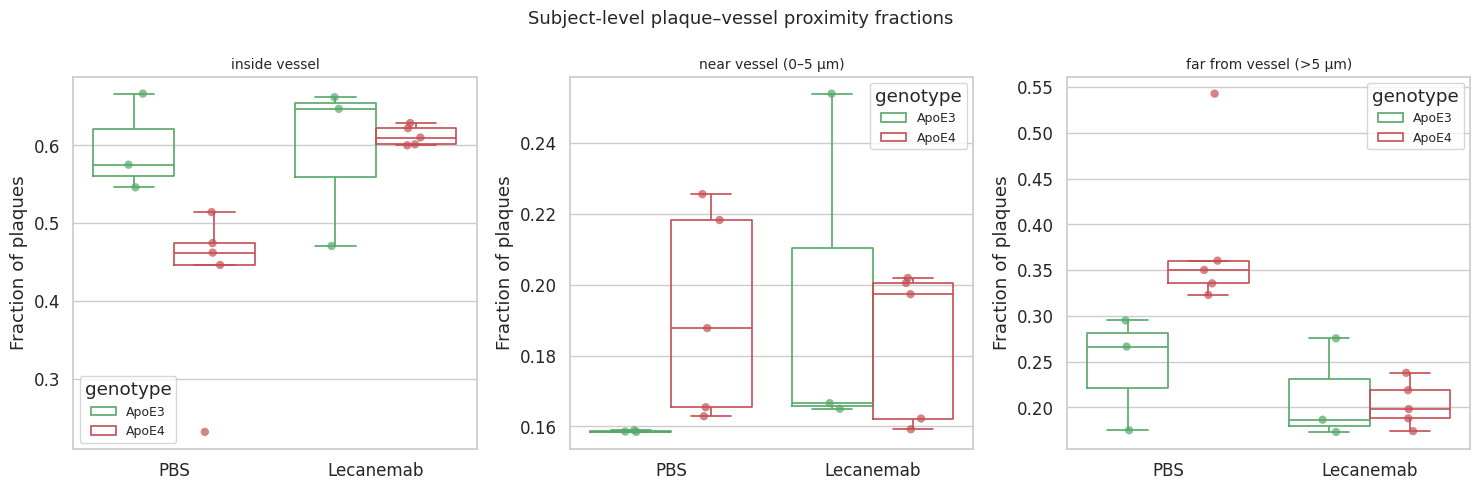

In [8]:
def boxstrip(ax, data, x, y, hue=None, order=None, hue_order=None, palette=None,
             ylabel=None, yscale="linear"):
    """Paired boxplot + stripplot helper (shared with treatment_effect_analysis)."""
    sns.boxplot(data=data, x=x, y=y, hue=hue,
                order=order, hue_order=hue_order, palette=palette,
                fill=False, linewidth=1.2, fliersize=0, ax=ax)
    sns.stripplot(data=data, x=x, y=y, hue=hue,
                  order=order, hue_order=hue_order, palette=palette,
                  dodge=True, alpha=0.7, size=6, jitter=True, ax=ax)
    if yscale != "linear":
        ax.set_yscale(yscale)
    if ylabel:
        ax.set_ylabel(ylabel)
    handles, labels = ax.get_legend_handles_labels()
    n = len(hue_order) if hue_order else 2
    ax.legend(handles[:n], labels[:n], title=hue, fontsize=9)


# one facet per proximity category
relation_categories = df["vessel_relation"].cat.categories.tolist()
fig, axes = plt.subplots(1, len(relation_categories),
                         figsize=(5 * len(relation_categories), 5))

for ax, cat in zip(axes, relation_categories):
    cat_data = subj_prox.loc[subj_prox["vessel_relation"] == cat]
    boxstrip(
        ax, cat_data,
        x="treatment", y="fraction",
        hue="genotype",
        order=TREAT_ORDER, hue_order=GENO_ORDER, palette=GENO_PALETTE,
        ylabel="Fraction of plaques",
    )
    ax.set_title(cat, fontsize=10)
    ax.set_xlabel("")

fig.suptitle("Subject-level plaque–vessel proximity fractions", fontsize=13)
plt.tight_layout()
plt.savefig("fig_proximity_fractions.png", dpi=150, bbox_inches="tight")
plt.show()

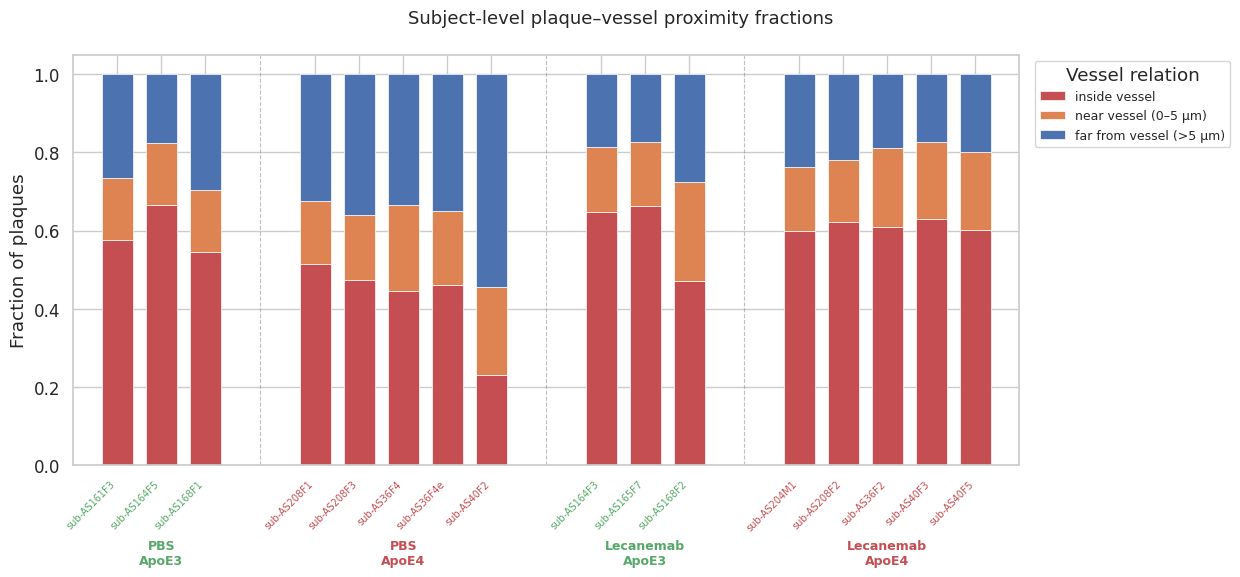

In [9]:
# ── Stacked bar: proximity fractions per subject, grouped by treatment × genotype ─
PROX_PALETTE = {
    relation_categories[0]: "#C44E52",  # inside vessel – red
    relation_categories[1]: "#DD8452",  # near vessel – orange/amber
    relation_categories[2]: "#4C72B0",  # far from vessel – blue
}

# Pivot to wide format: one row per subject, one column per proximity category
subj_prox_wide = (
    subj_prox
    .pivot_table(
        index=["subject", "treatment", "genotype"],
        columns="vessel_relation",
        values="fraction",
        observed=True,
    )
    .reset_index()
)
subj_prox_wide.columns.name = None

# Enforce treatment/genotype ordering then sort by subject within each group
subj_prox_wide["treatment"] = pd.Categorical(
    subj_prox_wide["treatment"], categories=TREAT_ORDER, ordered=True
)
subj_prox_wide["genotype"] = pd.Categorical(
    subj_prox_wide["genotype"], categories=GENO_ORDER, ordered=True
)
subj_prox_wide = subj_prox_wide.sort_values(
    ["treatment", "genotype", "subject"]
).reset_index(drop=True)

# Build x positions with gaps between treatment × genotype groups
gap = 1.5
bar_width = 0.7
group_order = [(t, g) for t in TREAT_ORDER for g in GENO_ORDER]
positions = []
group_centers = {}
x = 0.0
for treat, geno in group_order:
    mask = (
        (subj_prox_wide["treatment"] == treat)
        & (subj_prox_wide["genotype"] == geno)
    )
    n = mask.sum()
    if n == 0:
        continue
    pos = np.arange(x, x + n, dtype=float)
    positions.extend(pos)
    group_centers[(treat, geno)] = pos.mean()
    x += n + gap

positions = np.array(positions)

fig, ax = plt.subplots(figsize=(max(12, len(subj_prox_wide) * 0.6 + 3), 6))

bottoms = np.zeros(len(subj_prox_wide))
for cat in relation_categories:
    vals = subj_prox_wide[cat].fillna(0).values
    ax.bar(
        positions, vals, bottom=bottoms, width=bar_width,
        color=PROX_PALETTE[cat], label=cat, edgecolor="white", linewidth=0.5,
    )
    bottoms += vals

# X-tick labels = subject IDs, coloured by genotype
ax.set_xticks(positions)
ax.set_xticklabels(subj_prox_wide["subject"], rotation=45, ha="right", fontsize=7)
for tick, (_, row) in zip(ax.get_xticklabels(), subj_prox_wide.iterrows()):
    tick.set_color(GENO_PALETTE[row["genotype"]])

# Vertical separators between groups
group_keys = list(group_centers.keys())
for i in range(1, len(group_keys)):
    prev_key, curr_key = group_keys[i - 1], group_keys[i]
    prev_mask = (
        (subj_prox_wide["treatment"] == prev_key[0])
        & (subj_prox_wide["genotype"] == prev_key[1])
    )
    curr_mask = (
        (subj_prox_wide["treatment"] == curr_key[0])
        & (subj_prox_wide["genotype"] == curr_key[1])
    )
    sep_x = (positions[prev_mask.values].max() + positions[curr_mask.values].min()) / 2
    ax.axvline(sep_x, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

# Group labels (treatment × genotype) below the x-axis
for (treat, geno), cx in group_centers.items():
    ax.annotate(
        f"{treat}\n{geno}",
        xy=(cx, -0.18),
        xycoords=("data", "axes fraction"),
        ha="center", va="top", fontsize=9,
        color=GENO_PALETTE[geno], fontweight="bold",
    )

ax.set_xlim(positions[0] - 1, positions[-1] + 1)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Fraction of plaques")
ax.set_xlabel("")
ax.legend(title="Vessel relation", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
fig.suptitle("Subject-level plaque–vessel proximity fractions", fontsize=13)
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.savefig("fig_proximity_fractions_stacked.png", dpi=150, bbox_inches="tight")
plt.show()


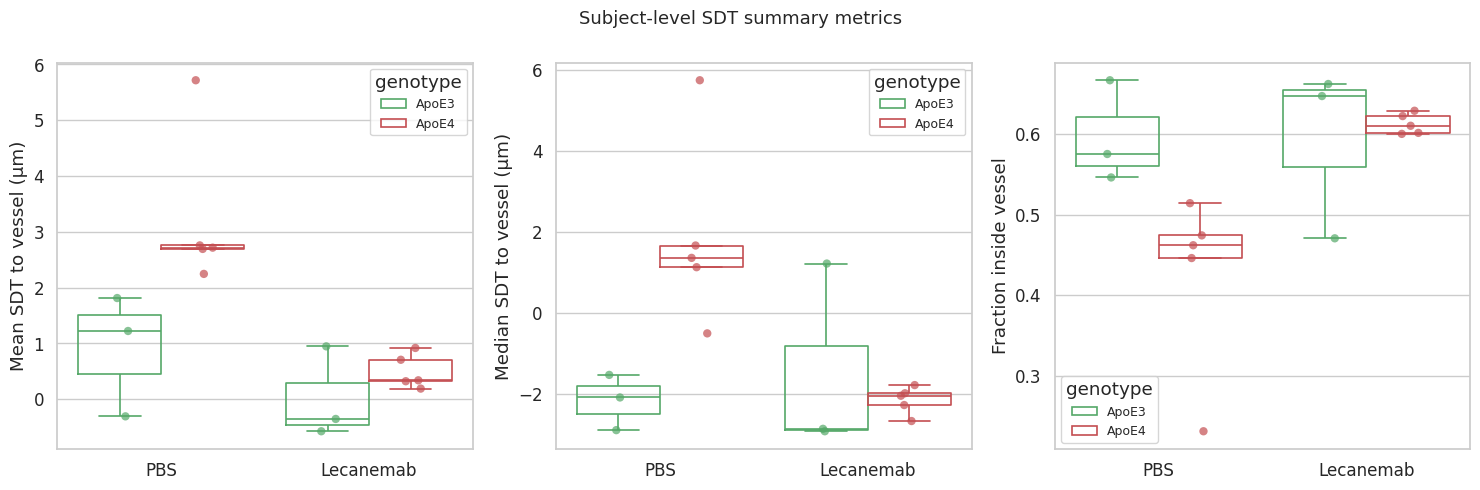

In [10]:
# ── Also show mean SDT per subject ───────────────────────────────────────────
subj_sdt = (
    df.groupby(["subject", "treatment", "genotype", "sex"], observed=True)
    .agg(
        mean_sdt_um   = ("sdt_CD31_um", "mean"),
        median_sdt_um = ("sdt_CD31_um", "median"),
        frac_inside   = ("sdt_CD31_um", lambda x: (x < 0).mean()),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = [
    ("mean_sdt_um",   "Mean SDT to vessel (µm)"),
    ("median_sdt_um", "Median SDT to vessel (µm)"),
    ("frac_inside",   "Fraction inside vessel"),
]

for ax, (col, label) in zip(axes, metrics):
    boxstrip(
        ax, subj_sdt,
        x="treatment", y=col,
        hue="genotype",
        order=TREAT_ORDER, hue_order=GENO_ORDER, palette=GENO_PALETTE,
        ylabel=label,
    )
    ax.set_xlabel("")

fig.suptitle("Subject-level SDT summary metrics", fontsize=13)
plt.tight_layout()
plt.show()

## 5  Two-way ANOVA: treatment × genotype

We test whether treatment or genotype (or their interaction) significantly predicts
the per-subject fraction of plaques in each proximity category, and the mean SDT.

In [11]:
def run_twoway_anova(data, outcome):
    """Two-way OLS ANOVA: outcome ~ C(treatment) * C(genotype).  Returns ANOVA table."""
    formula = f"{outcome} ~ C(treatment) * C(genotype)"
    model   = ols(formula, data=data).fit()
    return anova_lm(model, typ=2)


# ── proximity fraction ANOVA ──────────────────────────────────────────────────
print("=" * 70)
print("Two-way ANOVA (type II SS) — proximity fractions")
print("=" * 70)

anova_rows = []
for cat in relation_categories:
    cat_data = subj_prox.loc[subj_prox["vessel_relation"] == cat].copy()
    cat_data = cat_data.rename(columns={"fraction": "frac"})
    tbl = run_twoway_anova(cat_data, "frac")
    for term, row in tbl.iterrows():
        anova_rows.append({
            "Category": cat,
            "Term":     term,
            "F":        row.get("F", np.nan),
            "p-value":  row.get("PR(>F)", np.nan),
        })

# ── SDT metric ANOVA ─────────────────────────────────────────────────────────
for col, label in [("mean_sdt_um", "Mean SDT (µm)"), ("frac_inside", "Fraction inside vessel")]:
    tbl = run_twoway_anova(subj_sdt, col)
    for term, row in tbl.iterrows():
        anova_rows.append({
            "Category": label,
            "Term":     term,
            "F":        row.get("F", np.nan),
            "p-value":  row.get("PR(>F)", np.nan),
        })

anova_df = pd.DataFrame(anova_rows)
anova_df["sig"] = anova_df["p-value"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
)
print(anova_df.to_string(index=False))

Two-way ANOVA (type II SS) — proximity fractions
               Category                     Term         F  p-value sig
          inside vessel             C(treatment)  7.955996 0.015442   *
          inside vessel              C(genotype)  3.172264 0.100204    
          inside vessel C(treatment):C(genotype)  5.002294 0.045074   *
          inside vessel                 Residual       NaN      NaN    
   near vessel (0–5 µm)             C(treatment)  0.360962 0.559150    
   near vessel (0–5 µm)              C(genotype)  0.541128 0.476099    
   near vessel (0–5 µm) C(treatment):C(genotype)  2.113284 0.171674    
   near vessel (0–5 µm)                 Residual       NaN      NaN    
far from vessel (>5 µm)             C(treatment) 15.021105 0.002205  **
far from vessel (>5 µm)              C(genotype)  3.746899 0.076818    
far from vessel (>5 µm) C(treatment):C(genotype)  4.785357 0.049224   *
far from vessel (>5 µm)                 Residual       NaN      NaN    
          Mean 

In [12]:
# ── Post-hoc Tukey HSD for proximity fractions (inside vessel only) ────────────
inside_data = (
    subj_prox
    .loc[subj_prox["vessel_relation"] == "inside vessel"]
    .copy()
)
inside_data["group"] = inside_data["treatment"].astype(str) + "_" + inside_data["genotype"].astype(str)

tukey = pairwise_tukeyhsd(
    endog=inside_data["fraction"],
    groups=inside_data["group"],
    alpha=0.05,
)
print("Post-hoc Tukey HSD — fraction inside vessel:")
print(tukey.summary())

Post-hoc Tukey HSD — fraction inside vessel:
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
Lecanemab_ApoE3 Lecanemab_ApoE4   0.0193 0.9879 -0.1587  0.1973  False
Lecanemab_ApoE3       PBS_ApoE3   0.0027    1.0 -0.1963  0.2017  False
Lecanemab_ApoE3       PBS_ApoE4  -0.1676 0.0674 -0.3456  0.0104  False
Lecanemab_ApoE4       PBS_ApoE3  -0.0166 0.9922 -0.1946  0.1614  False
Lecanemab_ApoE4       PBS_ApoE4  -0.1869 0.0166  -0.341 -0.0327   True
      PBS_ApoE3       PBS_ApoE4  -0.1703 0.0623 -0.3483  0.0077  False
----------------------------------------------------------------------


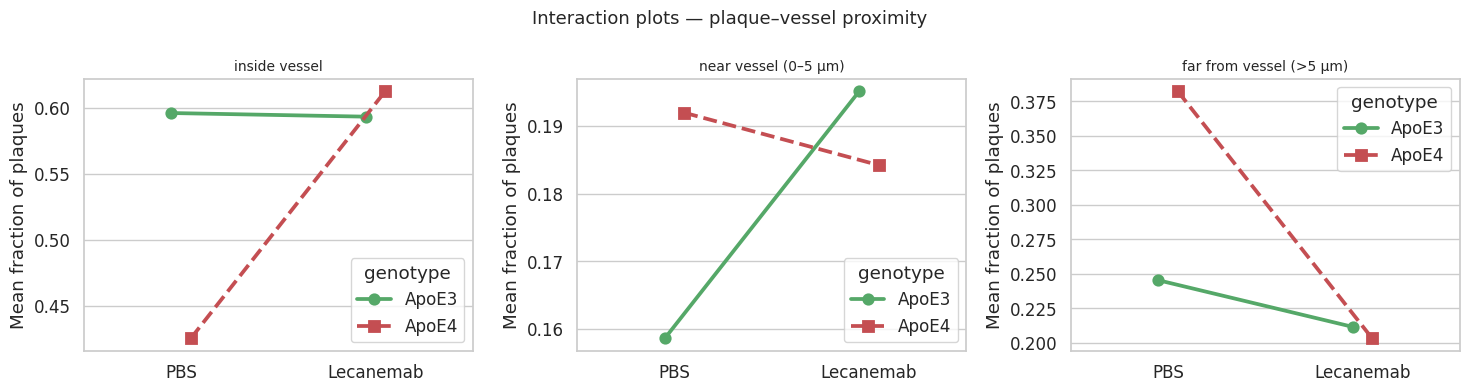

In [13]:
# ── Interaction plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(relation_categories),
                         figsize=(5 * len(relation_categories), 4))

for ax, cat in zip(axes, relation_categories):
    plot_df = (
        subj_prox
        .loc[subj_prox["vessel_relation"] == cat]
        .groupby(["treatment", "genotype"], observed=True)["fraction"]
        .mean()
        .reset_index()
    )
    sns.pointplot(
        data=plot_df,
        x="treatment", y="fraction",
        hue="genotype",
        order=TREAT_ORDER, hue_order=GENO_ORDER,
        palette=GENO_PALETTE,
        markers=["o", "s"],
        linestyles=["-", "--"],
        dodge=0.1,
        ax=ax,
    )
    ax.set_title(cat, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Mean fraction of plaques")

fig.suptitle("Interaction plots — plaque–vessel proximity", fontsize=13)
plt.tight_layout()
plt.savefig("fig_proximity_interaction.png", dpi=150, bbox_inches="tight")
plt.show()

## 6  Intravascular plaques: vessel-calibre estimation

For plaques whose `sdt_CD31_um < 0` (inside the vessel lumen), the minimum vessel
diameter compatible with the observation is:

$$d_{\text{vessel,min}} = d_{\text{plaque}} + 2 \cdot |\text{SDT}|$$

where $d_{\text{plaque}}$ is the equivalent spherical diameter of the plaque and
$|\text{SDT}|$ is the magnitude of the (negative) signed distance value.

A larger negative SDT means the plaque is deeper inside the vessel, implying a wider
lumen.

In [14]:
df_inside = df.loc[df["sdt_CD31_um"] < 0].copy()

print(f"Intravascular plaques: {len(df_inside):,}  "
      f"({100*len(df_inside)/len(df):.1f}% of filtered set)")
print()
print("SDT (µm) for intravascular plaques:")
print(df_inside["sdt_CD31_um"].describe().round(2))
print()
print("Estimated min vessel diameter (µm):")
print(df_inside["min_vessel_diam_um"].describe().round(2))

Intravascular plaques: 622,692  (53.8% of filtered set)

SDT (µm) for intravascular plaques:
count    622692.00
mean         -4.38
std           2.64
min         -40.72
25%          -5.62
50%          -3.97
75%          -2.63
max          -0.00
Name: sdt_CD31_um, dtype: float64

Estimated min vessel diameter (µm):
count    622692.00
mean         30.36
std          10.18
min          13.94
25%          23.39
50%          27.76
75%          34.56
max         125.55
Name: min_vessel_diam_um, dtype: float64


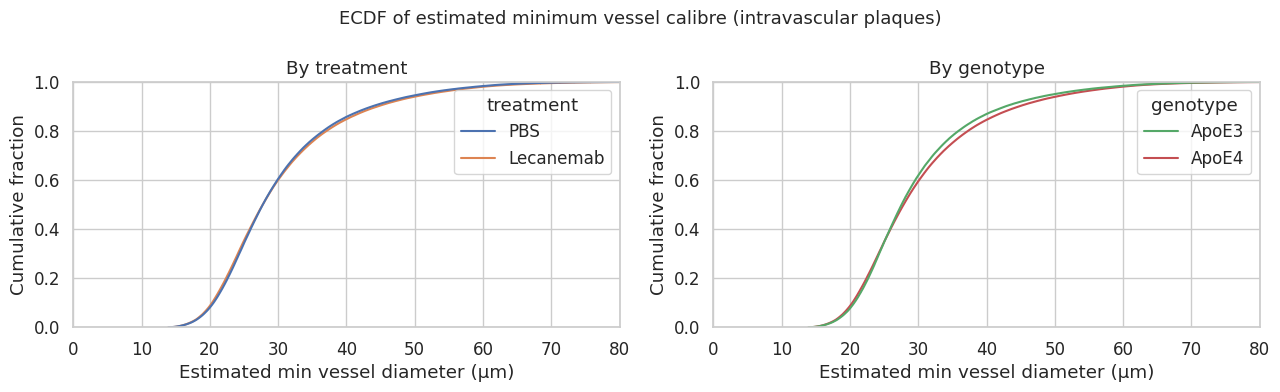

In [15]:
# ── Distribution of estimated vessel diameter ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (hue_col, hue_order, palette) in zip(
    axes,
    [
        ("treatment", TREAT_ORDER, TREAT_PALETTE),
        ("genotype",  GENO_ORDER,  GENO_PALETTE),
    ],
):
    sns.ecdfplot(
        data=df_inside,
        x="min_vessel_diam_um",
        hue=hue_col,
        hue_order=hue_order,
        palette=palette,
        ax=ax,
    )
    ax.set_xlabel("Estimated min vessel diameter (µm)")
    ax.set_ylabel("Cumulative fraction")
    ax.set_xlim(0, 80)

axes[0].set_title("By treatment")
axes[1].set_title("By genotype")
fig.suptitle("ECDF of estimated minimum vessel calibre (intravascular plaques)", fontsize=13)
plt.tight_layout()
plt.savefig("fig_vessel_calibre_ecdf.png", dpi=150, bbox_inches="tight")
plt.show()

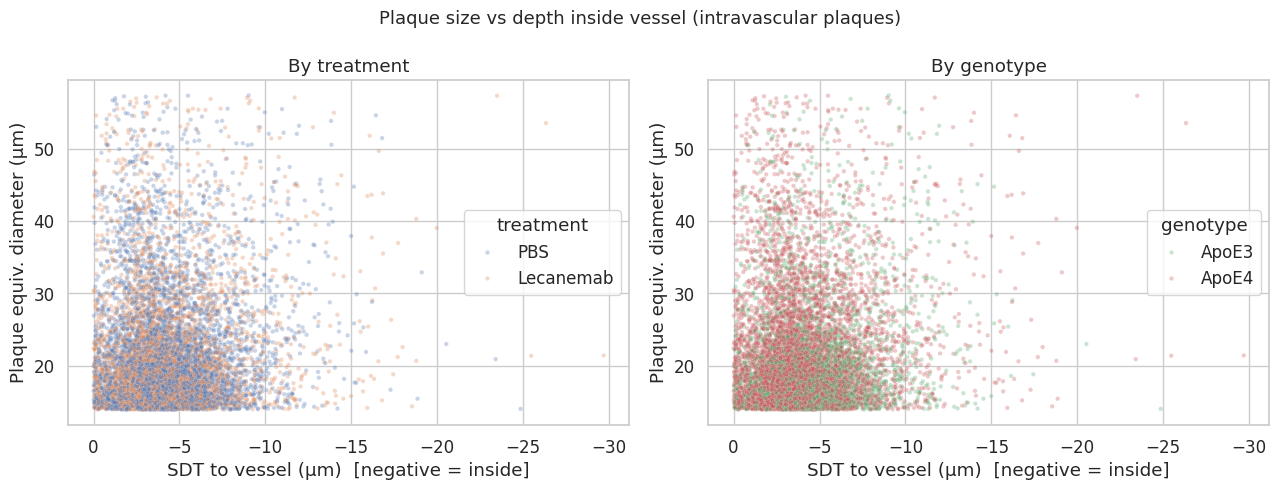

In [16]:
# ── Scatter: plaque size vs SDT for intravascular plaques ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (hue_col, hue_order, palette) in zip(
    axes,
    [
        ("treatment", TREAT_ORDER, TREAT_PALETTE),
        ("genotype",  GENO_ORDER,  GENO_PALETTE),
    ],
):
    sample = df_inside.sample(min(10_000, len(df_inside)), random_state=42)
    sns.scatterplot(
        data=sample,
        x="sdt_CD31_um",
        y="equiv_diam_um",
        hue=hue_col,
        hue_order=hue_order,
        palette=palette,
        alpha=0.3,
        s=10,
        ax=ax,
    )
    ax.set_xlabel("SDT to vessel (µm)  [negative = inside]")
    ax.set_ylabel("Plaque equiv. diameter (µm)")
    ax.invert_xaxis()   # more negative (deeper) to the right

axes[0].set_title("By treatment")
axes[1].set_title("By genotype")
fig.suptitle("Plaque size vs depth inside vessel (intravascular plaques)", fontsize=13)
plt.tight_layout()
plt.show()

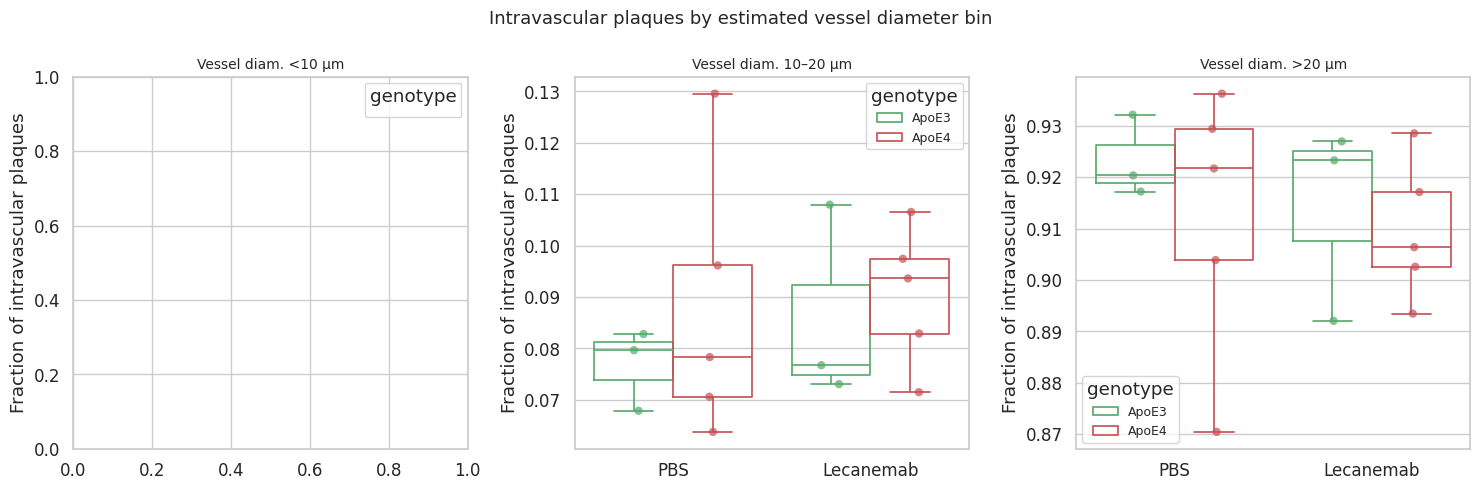

In [17]:
# ── Vessel-diameter bin fractions (subject level) ─────────────────────────────
def subject_vessel_diam_fractions(plaque_df,
                                  group_cols=("subject", "genotype", "treatment", "sex")):
    """Per-subject fraction of intravascular plaques in each vessel-diameter bin."""
    inside = plaque_df.loc[plaque_df["sdt_CD31_um"] < 0]
    counts = (
        inside.groupby(list(group_cols) + ["vessel_diam_bin"], observed=True)
        .size()
        .rename("n")
        .reset_index()
    )
    totals = (
        inside.groupby(list(group_cols), observed=True)
        .size()
        .rename("n_total")
        .reset_index()
    )
    out = counts.merge(totals, on=list(group_cols))
    out["fraction"] = out["n"] / out["n_total"]
    return out


subj_diam = subject_vessel_diam_fractions(df)
diam_bins = df["vessel_diam_bin"].cat.categories.tolist()

fig, axes = plt.subplots(1, len(diam_bins), figsize=(5 * len(diam_bins), 5))

for ax, bin_label in zip(axes, diam_bins):
    bin_data = subj_diam.loc[subj_diam["vessel_diam_bin"] == bin_label]
    boxstrip(
        ax, bin_data,
        x="treatment", y="fraction",
        hue="genotype",
        order=TREAT_ORDER, hue_order=GENO_ORDER, palette=GENO_PALETTE,
        ylabel="Fraction of intravascular plaques",
    )
    ax.set_title(f"Vessel diam. {bin_label}", fontsize=10)
    ax.set_xlabel("")

fig.suptitle("Intravascular plaques by estimated vessel diameter bin", fontsize=13)
plt.tight_layout()
plt.savefig("fig_vessel_diam_bins.png", dpi=150, bbox_inches="tight")
plt.show()

## 7  Subject-level vessel-calibre summaries

In [18]:
subj_calibre = (
    df_inside
    .groupby(["subject", "treatment", "genotype", "sex"], observed=True)
    .agg(
        n_intravascular      = ("min_vessel_diam_um", "size"),
        mean_min_diam_um     = ("min_vessel_diam_um", "mean"),
        median_min_diam_um   = ("min_vessel_diam_um", "median"),
        mean_sdt_inside_um   = ("sdt_CD31_um",        "mean"),
        median_sdt_inside_um = ("sdt_CD31_um",        "median"),
    )
    .reset_index()
)

print("Subject-level intravascular calibre metrics:")
print(subj_calibre[["subject", "treatment", "genotype",
                     "n_intravascular", "mean_min_diam_um", "median_sdt_inside_um"]].to_string(index=False))

Subject-level intravascular calibre metrics:
    subject treatment genotype  n_intravascular  mean_min_diam_um  median_sdt_inside_um
sub-AS161F3       PBS    ApoE3            43105         30.521043             -4.532187
sub-AS164F3 Lecanemab    ApoE3            39387         30.717701             -4.523153
sub-AS164F5       PBS    ApoE3            56225         29.016969             -4.217150
sub-AS165F7 Lecanemab    ApoE3            21819         30.075807             -4.353944
sub-AS168F1       PBS    ApoE3            47336         30.081033             -4.401537
sub-AS168F2 Lecanemab    ApoE3              352         30.045697             -4.226146
sub-AS204M1 Lecanemab    ApoE4            36192         30.324848             -4.328318
sub-AS208F1       PBS    ApoE4            57615         30.441248             -4.062728
sub-AS208F2 Lecanemab    ApoE4            42363         31.481588             -4.690507
sub-AS208F3       PBS    ApoE4            40108         31.616099          

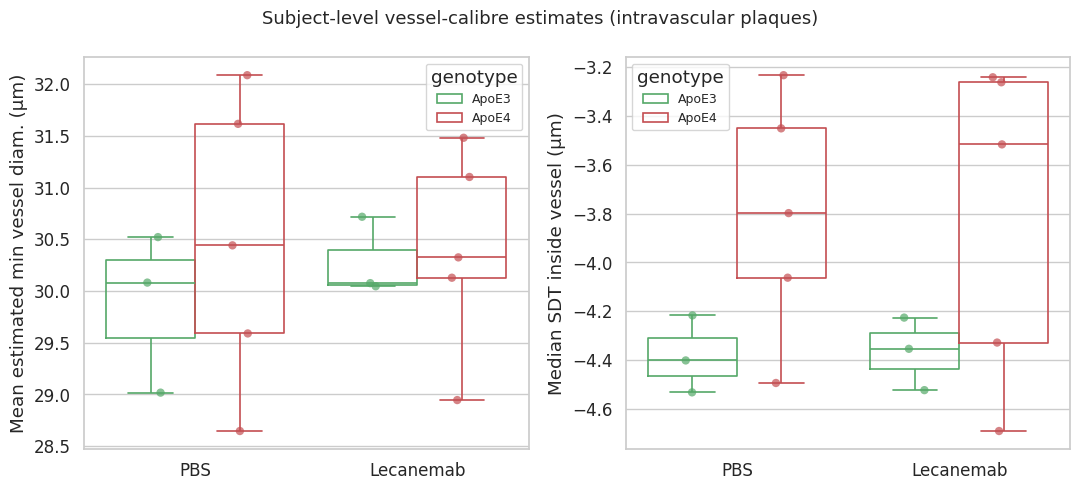

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
calibre_metrics = [
    ("mean_min_diam_um",   "Mean estimated min vessel diam. (µm)"),
    ("median_sdt_inside_um", "Median SDT inside vessel (µm)"),
]

for ax, (col, label) in zip(axes, calibre_metrics):
    boxstrip(
        ax, subj_calibre,
        x="treatment", y=col,
        hue="genotype",
        order=TREAT_ORDER, hue_order=GENO_ORDER, palette=GENO_PALETTE,
        ylabel=label,
    )
    ax.set_xlabel("")

fig.suptitle("Subject-level vessel-calibre estimates (intravascular plaques)", fontsize=13)
plt.tight_layout()
plt.savefig("fig_vessel_calibre_subject.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# ── ANOVA on calibre metrics ──────────────────────────────────────────────────
print("=" * 70)
print("Two-way ANOVA — vessel-calibre metrics (intravascular plaques)")
print("=" * 70)
calibre_anova_rows = []
for col, label in calibre_metrics:
    tbl = run_twoway_anova(subj_calibre, col)
    for term, row in tbl.iterrows():
        calibre_anova_rows.append({
            "Metric": label,
            "Term":   term,
            "F":      row.get("F", np.nan),
            "p-value": row.get("PR(>F)", np.nan),
        })
calibre_anova_df = pd.DataFrame(calibre_anova_rows)
calibre_anova_df["sig"] = calibre_anova_df["p-value"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
)
print(calibre_anova_df.to_string(index=False))

Two-way ANOVA — vessel-calibre metrics (intravascular plaques)
                              Metric                     Term        F  p-value sig
Mean estimated min vessel diam. (µm)             C(treatment) 0.038005 0.848694    
Mean estimated min vessel diam. (µm)              C(genotype) 0.435407 0.521811    
Mean estimated min vessel diam. (µm) C(treatment):C(genotype) 0.198734 0.663681    
Mean estimated min vessel diam. (µm)                 Residual      NaN      NaN    
       Median SDT inside vessel (µm)             C(treatment) 0.000582 0.981152    
       Median SDT inside vessel (µm)              C(genotype) 5.107714 0.043209   *
       Median SDT inside vessel (µm) C(treatment):C(genotype) 0.001017 0.975087    
       Median SDT inside vessel (µm)                 Residual      NaN      NaN    


## 8  2-D spatial maps coloured by vessel-proximity category

Scatter plots in template (Allen Brain Atlas) space, with a random down-sample for
visual clarity.  Points are coloured by the three-way proximity category.

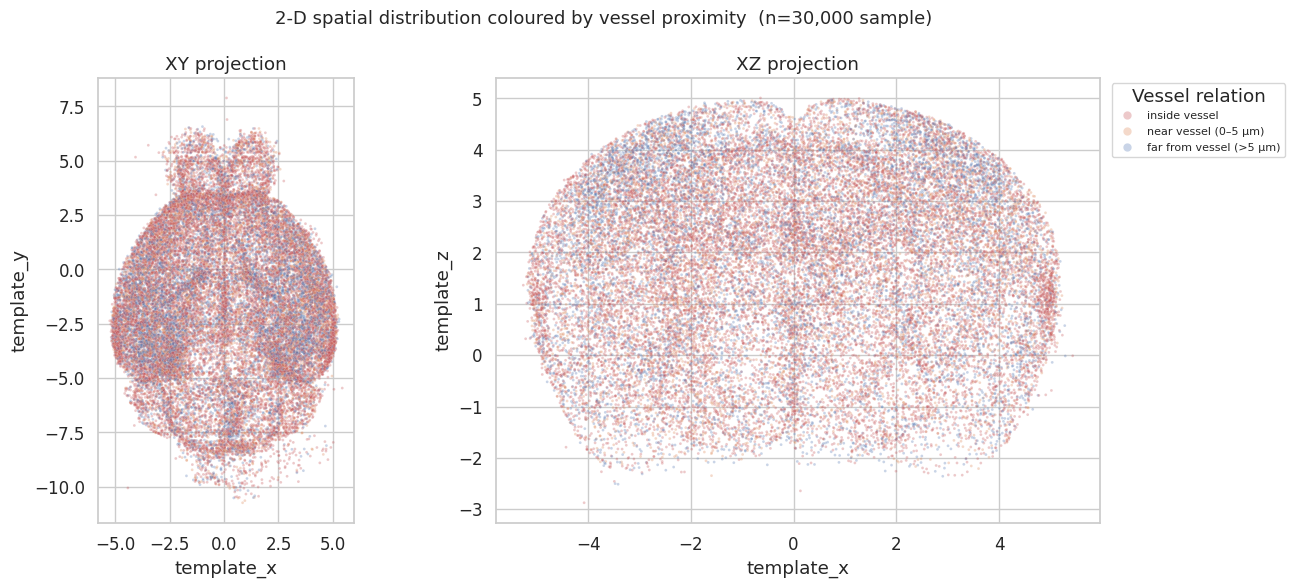

In [21]:
PROX_PALETTE = {
    "inside vessel":                      "#C44E52",
    f"near vessel (0–{TAU_UM:g} µm)":    "#DD8452",
    f"far from vessel (>{TAU_UM:g} µm)": "#4C72B0",
}

n_sample = 30_000
sample = df.sample(min(n_sample, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# xy projection
sns.scatterplot(
    data=sample,
    x="template_x", y="template_y",
    hue="vessel_relation",
    hue_order=relation_categories,
    palette=PROX_PALETTE,
    alpha=0.3, s=4,
    ax=axes[0],
)
axes[0].set_aspect("equal")
axes[0].set_title("XY projection")
axes[0].get_legend().remove()

# xz projection
sns.scatterplot(
    data=sample,
    x="template_x", y="template_z",
    hue="vessel_relation",
    hue_order=relation_categories,
    palette=PROX_PALETTE,
    alpha=0.3, s=4,
    ax=axes[1],
)
axes[1].set_aspect("equal")
axes[1].set_title("XZ projection")
axes[1].legend(
    title="Vessel relation",
    bbox_to_anchor=(1.01, 1), loc="upper left",
    fontsize=8, markerscale=3,
)

fig.suptitle(
    f"2-D spatial distribution coloured by vessel proximity  (n={n_sample:,} sample)",
    fontsize=13,
)
plt.tight_layout()
plt.savefig("fig_spatial_vessel_proximity.png", dpi=150, bbox_inches="tight")
plt.show()

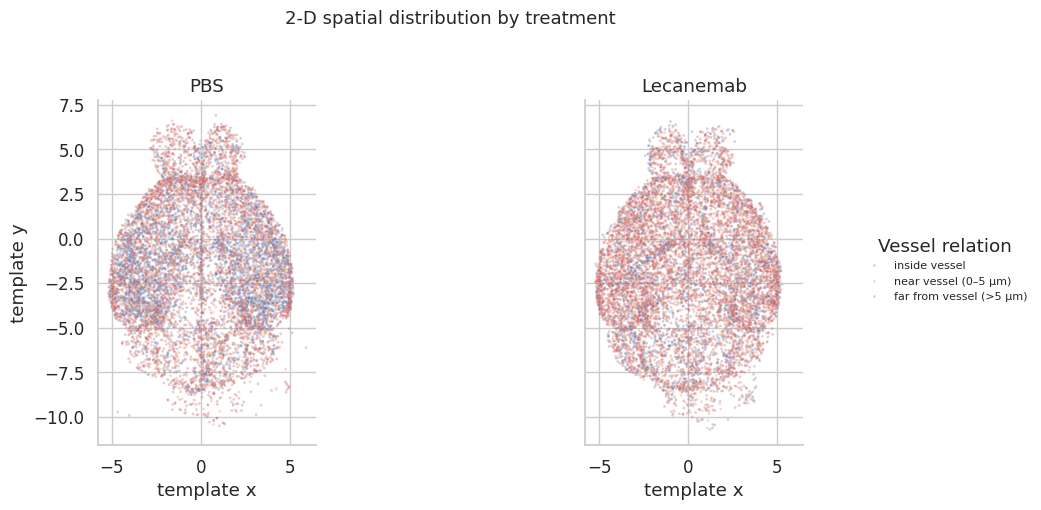

In [22]:
# ── Facet by treatment ────────────────────────────────────────────────────────
sample_treat = pd.concat(
    [
        grp.sample(min(10_000, len(grp)), random_state=42)
        for _, grp in df.groupby("treatment", observed=True)
    ],
    ignore_index=True,
)

g = sns.FacetGrid(
    sample_treat,
    col="treatment",
    col_order=TREAT_ORDER,
    height=5,
    aspect=1,
)
g.map_dataframe(
    sns.scatterplot,
    x="template_x", y="template_y",
    hue="vessel_relation",
    hue_order=relation_categories,
    palette=PROX_PALETTE,
    alpha=0.3, s=4,
)
g.set_titles("{col_name}")
g.set_axis_labels("template x", "template y")
for ax in g.axes.flat:
    ax.set_aspect("equal")
g.add_legend(title="Vessel relation", bbox_to_anchor=(1, 0.5), fontsize=8)
g.figure.suptitle("2-D spatial distribution by treatment", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()